In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.simplefilter("ignore")
import omicverse as ov
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.11, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [2]:
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
adata = sc.read("/home/lugli/spuccio/Projects/SP039/GBmap/Tcell_RawData.h5ad")

In [4]:
adata.shape

(33161, 15452)

In [5]:
adata.obs.head()

,donor_id,Author,stage,assay,tissue,Cells,Method,n_genes,nUMIs,annotation_level_1,...,scsa_celltype_cellmarker,scsa_celltype_panglaodb,cell_type,S_score,G2M_score,phase,leiden,cnv_leiden,cnv_score,cnv_status
Cell6,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,1201,1317.797852,Non-neoplastic,...,T cell,T Cells,mature T cell,-0.375458,0.187930,G2M,4,5,0.006147,normal
Cell36,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,871,1275.448486,Non-neoplastic,...,T cell,T Cells,mature T cell,-0.108176,0.183254,G2M,4,5,0.006147,normal
Cell41,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,865,1227.074585,Non-neoplastic,...,T cell,T Cells,mature T cell,-0.325519,-0.090387,G1,4,5,0.006147,normal
Cell48,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,2784,1757.278076,Neoplastic,...,T cell,T Cells,malignant cell,-0.049835,-0.207362,G1,4,5,0.006147,normal
Cell64,ndGBM-01,Abdelfattah2022,Primary,10x 3' v3,frontal lobe,Total,cell,1167,1430.446167,Non-neoplastic,...,T cell,T Cells,mature T cell,-0.117193,-0.042341,G1,4,5,0.006147,normal


In [6]:
import numpy as np
print(adata.n_obs, adata.n_vars)
mito_genes = adata.var_names.str.startswith('MT')
ribo_genes = adata.var_names.str.startswith(("RPS","RPL"))
hb_genes = adata.var_names.str.startswith(("^HB[^(P)]"))
remove = np.add(ribo_genes, mito_genes,hb_genes)
keep = np.invert(remove)

adata = adata[:,keep]

print(adata.n_obs, adata.n_vars)

33161 15452
33161 15276


In [7]:
adata = adata[~adata.obs['scsa_celltype_panglaodb'].isin(['Unknown']),]

In [8]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',
                       n_HVGs=2000,batch_key="Author")
adata

Begin robust gene identification
After filtration, 15194/15276 genes are kept.     Among 15194 genes, 14025 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GNLY', 'HSPA1A', 'HSPA6', 'SEC61G']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 6.256366729736328 seconds.
End of size normalization: shiftlog and HVGs selection pearson


AnnData object with n_obs × n_vars = 33161 × 14025
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    layers: 'counts'

In [9]:
list(adata[:,adata.var['highly_variable_features'].isin([True])].var.index)

['A2M',
 'AAK1',
 'AATK',
 'ABCA1',
 'ABCB1',
 'ABCB9',
 'ABHD17A',
 'ABLIM1',
 'ABTB1',
 'ACP5',
 'ACSL1',
 'ACSL6',
 'ACTB',
 'ACTG2',
 'ACVR1C',
 'ACVR2A',
 'ADAM19',
 'ADAM23',
 'ADAM28',
 'ADAM8',
 'ADAMTS6',
 'ADAMTS9',
 'ADCY9',
 'ADD3',
 'ADGRE2',
 'ADGRE5',
 'ADGRF3',
 'ADGRG1',
 'ADGRG3',
 'ADM',
 'ADRB2',
 'ADTRP',
 'AFF3',
 'AGBL3',
 'AGMO',
 'AGPAT4',
 'AHI1',
 'AHNAK',
 'AHSA1',
 'AIF1',
 'AIMP1',
 'AK1',
 'AK5',
 'AK9',
 'AKAP12',
 'AKAP13',
 'AKAP6',
 'AKAP9',
 'AKIRIN2',
 'AKNA',
 'ALCAM',
 'ALDOA',
 'ALOX5AP',
 'AMD1',
 'AMDHD2',
 'AMIGO2',
 'AMY2B',
 'AMZ1',
 'ANAPC16',
 'ANGPT2',
 'ANGPTL4',
 'ANK3',
 'ANKRD11',
 'ANKRD12',
 'ANKRD28',
 'ANKRD33B',
 'ANKRD36C',
 'ANKRD37',
 'ANKRD44',
 'ANKRD49',
 'ANKRD55',
 'ANKRD6',
 'ANKS1B',
 'ANP32B',
 'ANTXR2',
 'ANXA1',
 'ANXA2',
 'ANXA2R',
 'ANXA5',
 'AOAH',
 'AP3M2',
 'AP4E1',
 'APMAP',
 'APOBEC3C',
 'APOBEC3G',
 'APOC1',
 'APOC2',
 'APOD',
 'APOE',
 'APOLD1',
 'APP',
 'APRT',
 'AQP3',
 'AQP4',
 'ARAP2',
 'ARC',
 'AREG',
 

In [10]:
adata.raw = adata

In [11]:
adata.layers['lognorm'] = adata.X

In [12]:

adata = adata[:, adata.var.highly_variable_features]
adata

View of AnnData object with n_obs × n_vars = 33161 × 2000
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    layers: 'counts', 'lognorm'

In [13]:
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)
adata.obsm['X_pca']=adata.obsm['scaled|original|X_pca']

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:10)


<AxesSubplot: title={'center': 'Author'}, xlabel='X_pca1', ylabel='X_pca2'>

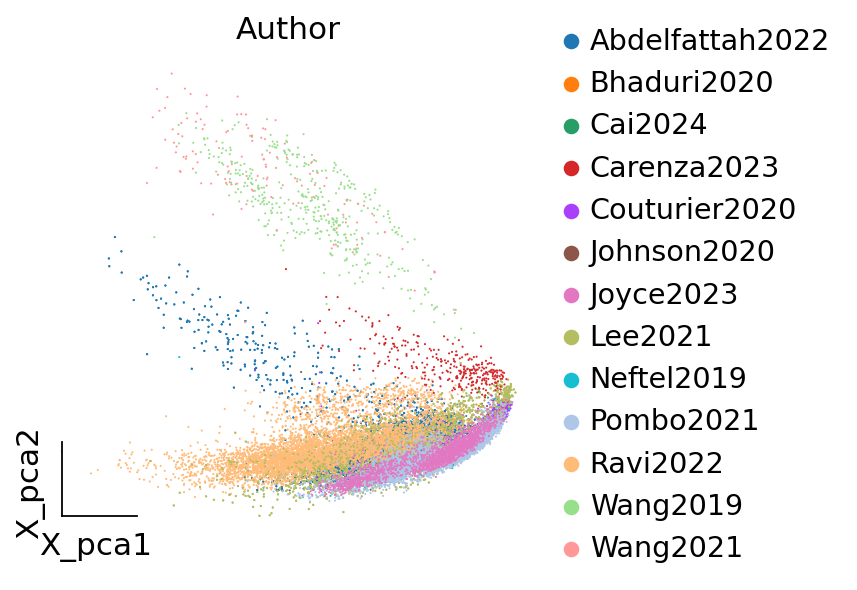

In [14]:
ov.utils.embedding(adata,
                basis='X_pca',frameon='small',
                color=['Author'],show=False,wspace=0.5)

<AxesSubplot: title={'center': 'CD3E'}, xlabel='X_pca1', ylabel='X_pca2'>

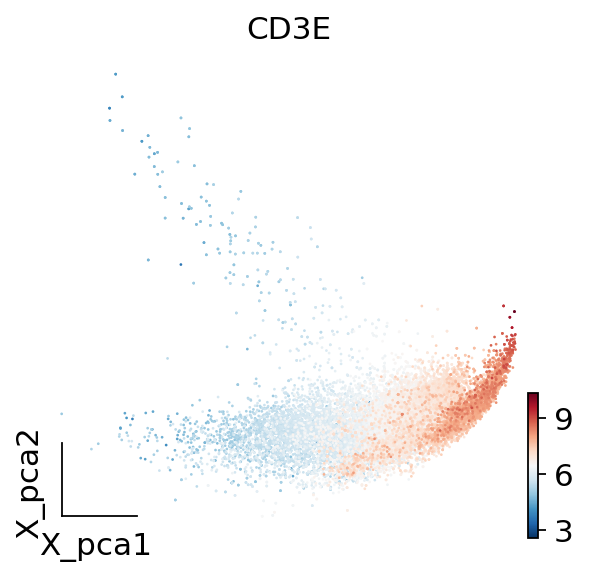

In [15]:
ov.utils.embedding(adata[adata[:, "CD3E"].X >= 0.1],
                basis='X_pca',frameon='small',
                color=['CD3E'],show=False,wspace=0.5)

In [16]:
adata = adata[adata[:, "CD3E"].X >= 0.1]

In [17]:
adata.obs['Author'].value_counts()

Author
Abdelfattah2022    8664
Ravi2022           3479
Pombo2021          3337
Lee2021            1918
Joyce2023          1607
Couturier2020       566
Cai2024             285
Neftel2019          213
Johnson2020          20
Bhaduri2020          17
Name: count, dtype: int64

In [18]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)


In [19]:
%%time
ov.pp.umap(adata)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:15)
CPU times: user 16.4 s, sys: 3.55 s, total: 20 s
Wall time: 15.4 s


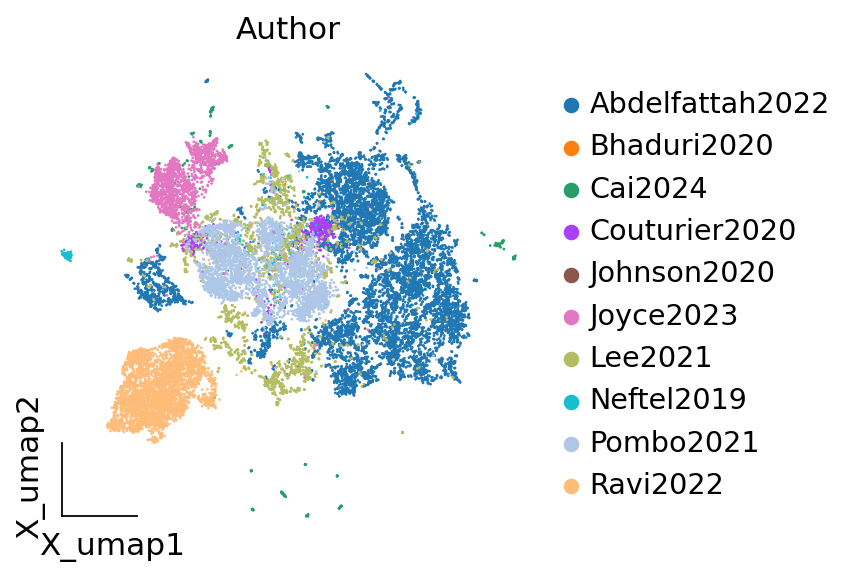

In [20]:
ov.pl.embedding(adata,
                basis='X_umap',
                color='Author',
                frameon='small')

In [21]:
ov.single.batch_correction(adata,batch_key=['Author','assay'],
                                        methods='harmony',n_pcs=30)
adata

...Begin using harmony to correct batch effect


2025-05-16 11:36:44,883 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-05-16 11:36:48,756 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-05-16 11:36:48,824 - harmonypy - INFO - Iteration 1 of 10
2025-05-16 11:36:53,604 - harmonypy - INFO - Iteration 2 of 10
2025-05-16 11:36:58,359 - harmonypy - INFO - Iteration 3 of 10
2025-05-16 11:37:03,064 - harmonypy - INFO - Iteration 4 of 10
2025-05-16 11:37:07,752 - harmonypy - INFO - Iteration 5 of 10
2025-05-16 11:37:12,064 - harmonypy - INFO - Iteration 6 of 10
2025-05-16 11:37:15,761 - harmonypy - INFO - Iteration 7 of 10
2025-05-16 11:37:18,942 - harmonypy - INFO - Iteration 8 of 10
2025-05-16 11:37:21,838 - harmonypy - INFO - Iteration 9 of 10
2025-05-16 11:37:24,524 - harmonypy - INFO - Iteration 10 of 10
2025-05-16 11:37:27,225 - harmonypy - INFO - Stopped before convergence


AnnData object with n_obs × n_vars = 20106 × 2000
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'ensembl_gene_id', 'start_position', 'end_position', 'chromosome_name', 'gene_biotype', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'Author_colors', 'neighbors', 'umap'
    obsm: 'X_cnv', 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'lognorm', 'scaled'
    obsp: 'distances', 'connectivities

In [22]:
adata.obsm['X_harmony'].shape

(20106, 50)

In [23]:
#adata.obsm['X_pca'] = adata.obsm['X_harmony']

In [24]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


In [25]:
%%time
ov.pp.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:15)
CPU times: user 15.4 s, sys: 1.82 s, total: 17.2 s
Wall time: 15.1 s


In [26]:
#adata = adata[~adata.obs['scsa_celltype_cellmarker'].isin(['Unknown']),:]

ov.pl.embedding(adata,
                basis='X_umap',
                color=['annotation_level_2'],wspace=0.5,ncols=1,
                frameon='small')

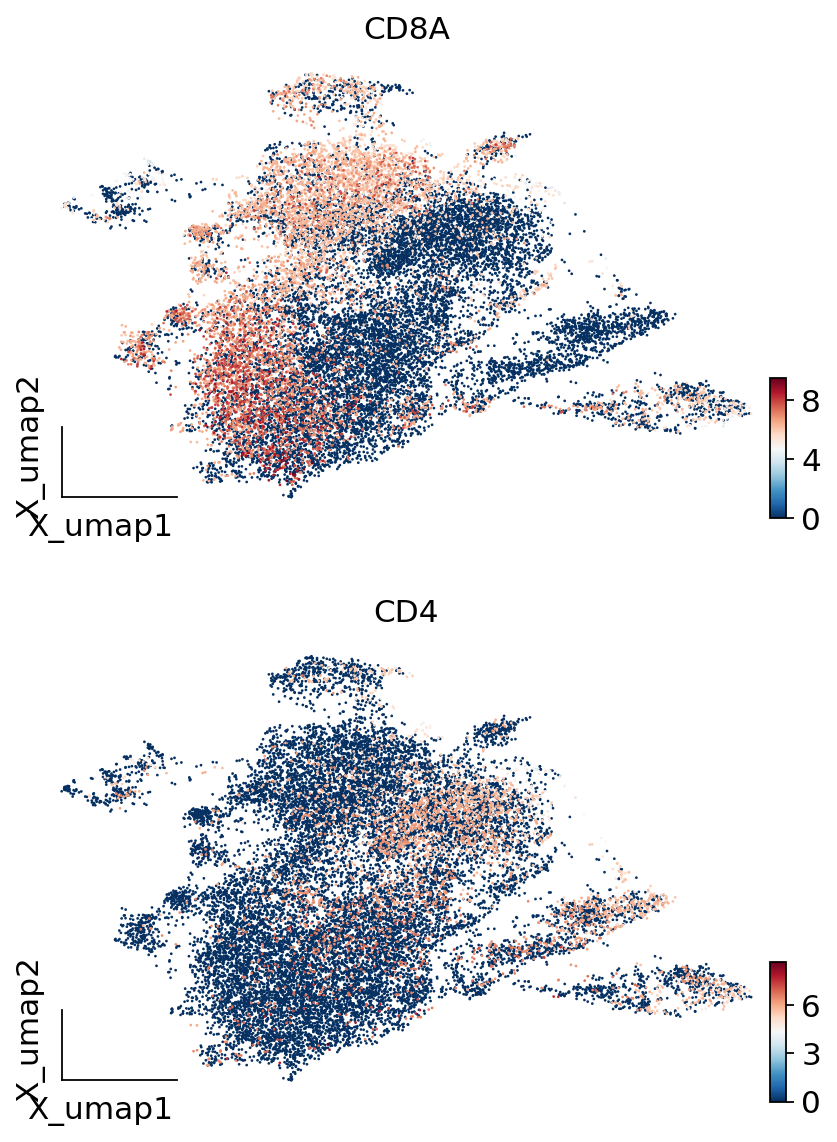

In [27]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD8A','CD4'],wspace=0.5,ncols=1,
                frameon='small')

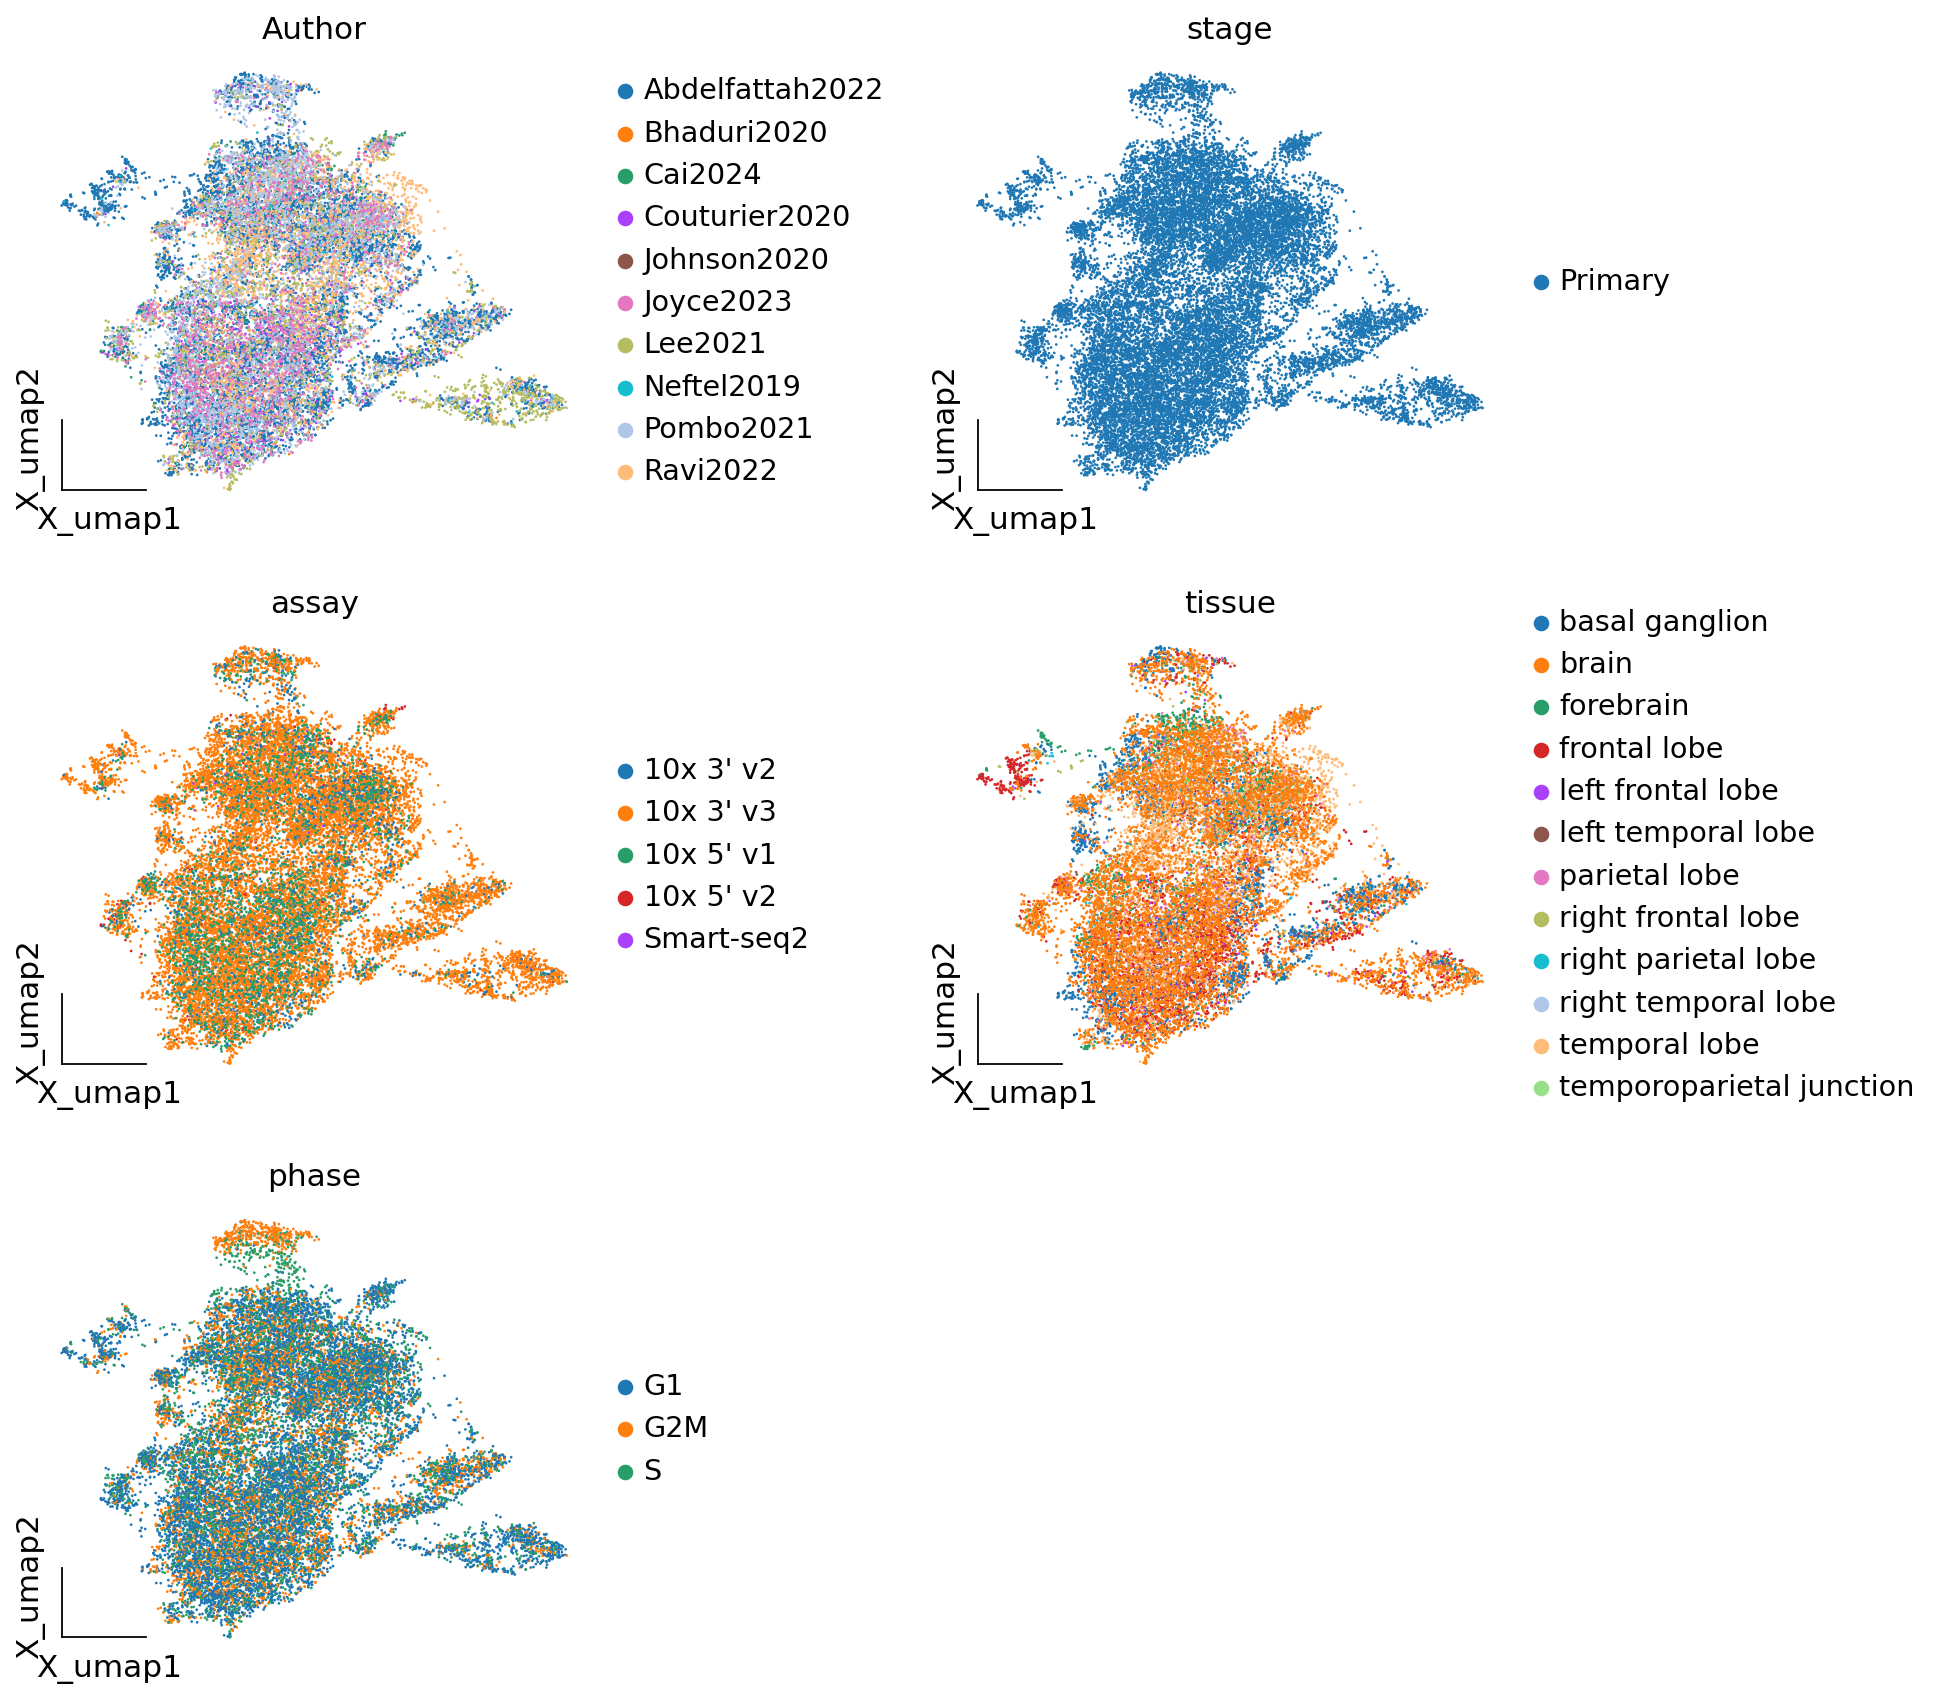

In [28]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['Author','stage','assay','tissue','phase'],wspace=0.5,ncols=2,
                frameon='small')

In [29]:
#adata.write("/home/lugli/spuccio/Projects/SP039/GBmap/RawDataAfterIntegrationHarmony.h5ad")

In [30]:
ov.utils.cluster(adata,method='leiden',resolution=0.2)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:06)


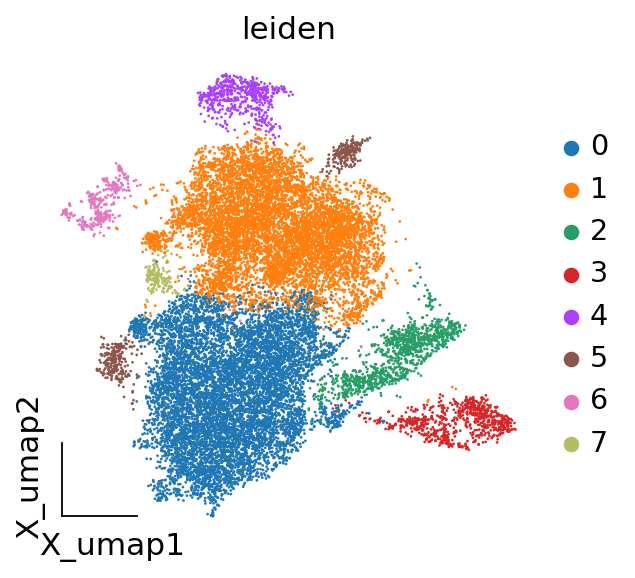

In [31]:
ov.utils.embedding(adata,basis='X_umap',
                   color=['leiden'],
                   frameon='small',wspace=0.5)

In [38]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon',use_raw=False,pts=0.20)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)


In [39]:
result = adata.uns['rank_genes_groups']

In [40]:
groups = result['names'].dtype.names
with pd.ExcelWriter('/home/lugli/spuccio/Projects/SP039/GBmap/Res02.xlsx') as writer:
    for _ in range(len(groups)):
        sc.get.rank_genes_groups_df(adata, group=groups[_],key='rank_genes_groups').to_excel(writer, sheet_name=groups[_],index=False)
        

In [41]:
import pandas as pd

In [42]:
ov.utils.cluster(adata,method='leiden',resolution=0.4)

running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:10)


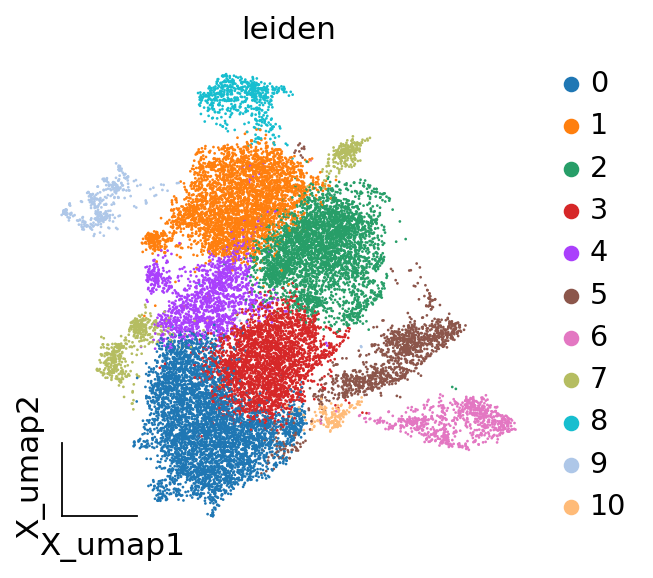

In [43]:
ov.utils.embedding(adata,basis='X_umap',
                   color=['leiden'],
                   frameon='small',wspace=0.5)

In [44]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon',use_raw=False,pts=0.20)
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(50)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)


,0,1,2,3,4,5,6,7,8,9,10
0,CD3E,CD8B,KLRB1,IL7R,GZMK,IL2RA,TYROBP,GNLY,STMN1,PTN,ISG15
1,FAU,CD8A,IL7R,S100A4,CST7,BATF,C1QB,NKG7,MKI67,PTPRZ1,IFI6
2,EIF1,NKG7,RORA,SARAF,NKG7,TIGIT,C1QC,KLRD1,TYMS,GPM6B,MX1
3,FTL,GZMH,CD40LG,TOMM7,GZMA,UGP2,C1QA,GZMB,PCLAF,TUBB2B,IFI44L
4,PTMA,GZMK,BCL2,CD3E,GZMH,FOXP3,APOC1,PRF1,TOP2A,NOVA1,STAT1
5,UBA52,APOBEC3G,XBP1,UBA52,TUBA4A,TNFRSF18,APOE,CTSW,NUSAP1,SOX2,IFIT3
6,TMSB10,CTSW,NDFIP1,PABPC1,DUSP4,TNFRSF4,FCER1G,FGFBP2,CKS1B,IGFBP2,IFIT1
7,ATP5F1E,ITM2C,DPP4,RACK1,CD27,IKZF2,NPC2,CST7,UBE2C,FABP7,ISG20
8,BTG1,IKZF3,ERN1,BTG1,CD8A,RTKN2,CST3,GZMH,CENPF,CLU,EPSTI1
9,HLA-E,SAMD3,CDC14A,COX7C,APOBEC3G,CTLA4,AIF1,ZEB2,ASPM,MAP1B,MX2


In [45]:
result = adata.uns['rank_genes_groups']

In [46]:
groups = result['names'].dtype.names
with pd.ExcelWriter('/home/lugli/spuccio/Projects/SP039/GBmap/Res04.xlsx') as writer:
    for _ in range(len(groups)):
        sc.get.rank_genes_groups_df(adata, group=groups[_]).to_excel(writer, sheet_name=groups[_],index=False)  

In [47]:
ov.utils.cluster(adata,method='leiden',resolution=0.6)

running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:12)


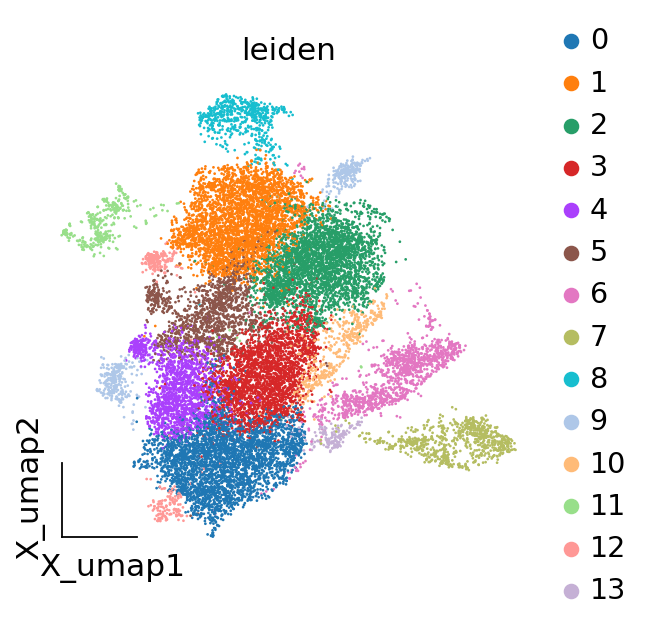

In [48]:
ov.utils.embedding(adata,basis='X_umap',
                   color=['leiden'],
                   frameon='small',wspace=0.5)

In [49]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon',use_raw=False,pts=0.20)
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(50)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,CD3E,CD8B,KLRB1,IL7R,NKG7,GZMK,IL2RA,TYROBP,STMN1,GNLY,KLF2,PTN,IKZF3,ISG15
1,FAU,CD8A,RORA,KLRB1,GZMA,CST7,BATF,C1QB,MKI67,NKG7,SOCS3,PTPRZ1,MACF1,IFI6
2,FTL,NKG7,CD40LG,S100A4,HCST,NKG7,TIGIT,C1QC,TYMS,GZMB,IL7R,GPM6B,DDX17,MX1
3,EIF1,GZMH,IL7R,S100A10,CD3E,DUSP4,UGP2,C1QA,PCLAF,FGFBP2,CCR7,TUBB2B,RNF213,IFI44L
4,PTMA,CTSW,DPP4,SARAF,ATP5F1E,GZMH,FOXP3,APOC1,TOP2A,KLRD1,CD55,NOVA1,MBNL1,STAT1
5,UBA52,APOBEC3G,TRADD,S100A11,CD8A,GZMA,TNFRSF4,APOE,NUSAP1,GZMH,AREG,SOX2,SYNE1,IFIT3
6,TMSB10,ITM2C,ERN1,TOMM7,HLA-E,TUBA4A,TNFRSF18,FCER1G,CKS1B,PRF1,SELL,IGFBP2,ITGA4,IFIT1
7,BTG1,GZMK,BCL2,CD3E,CFL1,CEMIP2,IKZF2,NPC2,UBE2C,CST7,PABPC1,CLU,SAMD3,ISG20
8,FTH1,SAMD3,XBP1,COX7C,SH3BGRL3,CD27,RTKN2,CST3,CENPF,CTSW,NOP53,FABP7,N4BP2L2,EPSTI1
9,EEF1A1,IKZF3,ADAM19,FXYD5,IL32,CRTAM,CTLA4,AIF1,ASPM,ZEB2,EIF3E,MAP1B,ANKRD44,RNF213


In [50]:
result = adata.uns['rank_genes_groups']

In [51]:
groups = result['names'].dtype.names
with pd.ExcelWriter('/home/lugli/spuccio/Projects/SP039/GBmap/Res06.xlsx') as writer:
    for _ in range(len(groups)):
        sc.get.rank_genes_groups_df(adata, group=groups[_]).to_excel(writer, sheet_name=groups[_],index=False)  

In [52]:
ov.utils.cluster(adata,method='leiden',resolution=0.8)

running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:09)


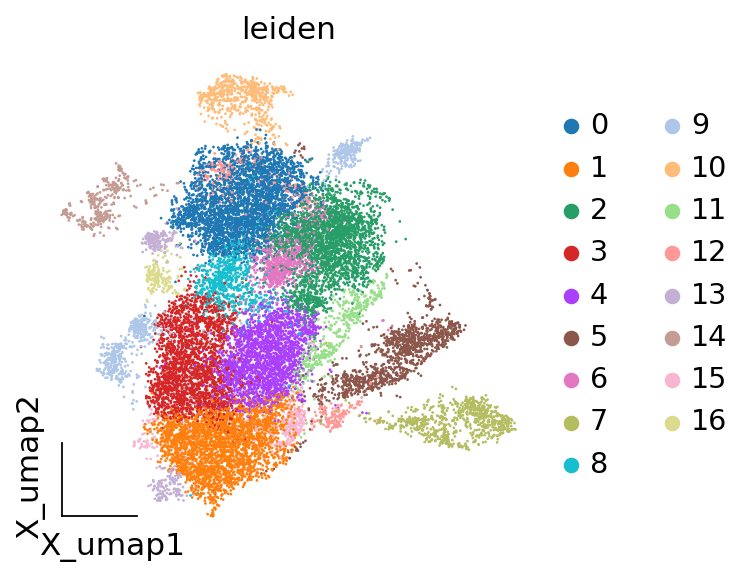

In [53]:
ov.utils.embedding(adata,basis='X_umap',
                   color=['leiden'],
                   frameon='small',wspace=0.5)

In [54]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon',use_raw=False,pts=0.20)
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(50)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,CD8B,CD3E,KLRB1,GZMA,IL7R,IL2RA,BCL2,TYROBP,YPEL5,GNLY,STMN1,KLF2,ISG15,IKZF3,PTN,HSPH1,VCAM1
1,CD8A,FAU,IL7R,GZMK,S100A4,BATF,OXNAD1,C1QB,TUBB4B,NKG7,MKI67,SOCS3,MX1,MACF1,PTPRZ1,HSPD1,LYST
2,NKG7,FTL,RORA,NKG7,KLRB1,TIGIT,CORO1B,C1QC,ZNF331,GZMB,TYMS,IL7R,IFI6,RNF213,GPM6B,HSPE1,CXCL13
3,GZMH,PTMA,ERN1,CST7,CD3E,UGP2,TRADD,C1QA,NR4A2,KLRD1,PCLAF,CCR7,STAT1,DDX17,TUBB2B,HSPA1A,CMC1
4,APOBEC3G,EIF1,NFKBIZ,CD3E,S100A10,FOXP3,CAPG,APOC1,IFRD1,PRF1,TOP2A,CD55,IFIT3,MBNL1,NOVA1,CACYBP,PTMS
5,ITM2C,TMSB10,PDE4D,HCST,TOMM7,TNFRSF18,MDFIC,APOE,UBE2S,CTSW,NUSAP1,NOP53,IFI44L,SYNE1,SOX2,DNAJA1,NKG7
6,CTSW,UBA52,PTGER4,ATP5F1E,VIM,TNFRSF4,CD40LG,FCER1G,SERTAD1,FGFBP2,CKS1B,SELL,IFIT1,ANKRD44,IGFBP2,DNAJB1,LAG3
7,GZMK,FTH1,GPR183,GZMH,S100A6,IKZF2,NCF1,NPC2,GZMK,CST7,UBE2C,EIF3E,EPSTI1,N4BP2L2,FABP7,HSPB1,GZMK
8,SAMD3,BTG1,TOB1,CFL1,S100A11,RTKN2,CISH,CST3,CEMIP2,GZMH,CENPF,AREG,MX2,SYNE2,MAP1B,HSP90AB1,CD27
9,IKZF3,EEF1A1,CRYBG1,HLA-E,COX7C,CTLA4,TNFAIP8,AIF1,RGCC,ZEB2,ASPM,PABPC1,TRIM22,AAK1,CLU,HSPA6,CCND2


In [55]:
result = adata.uns['rank_genes_groups']

In [56]:
groups = result['names'].dtype.names
with pd.ExcelWriter('/home/lugli/spuccio/Projects/SP039/GBmap/Res08.xlsx') as writer:
    for _ in range(len(groups)):
        sc.get.rank_genes_groups_df(adata, group=groups[_]).to_excel(writer, sheet_name=groups[_],index=False)  

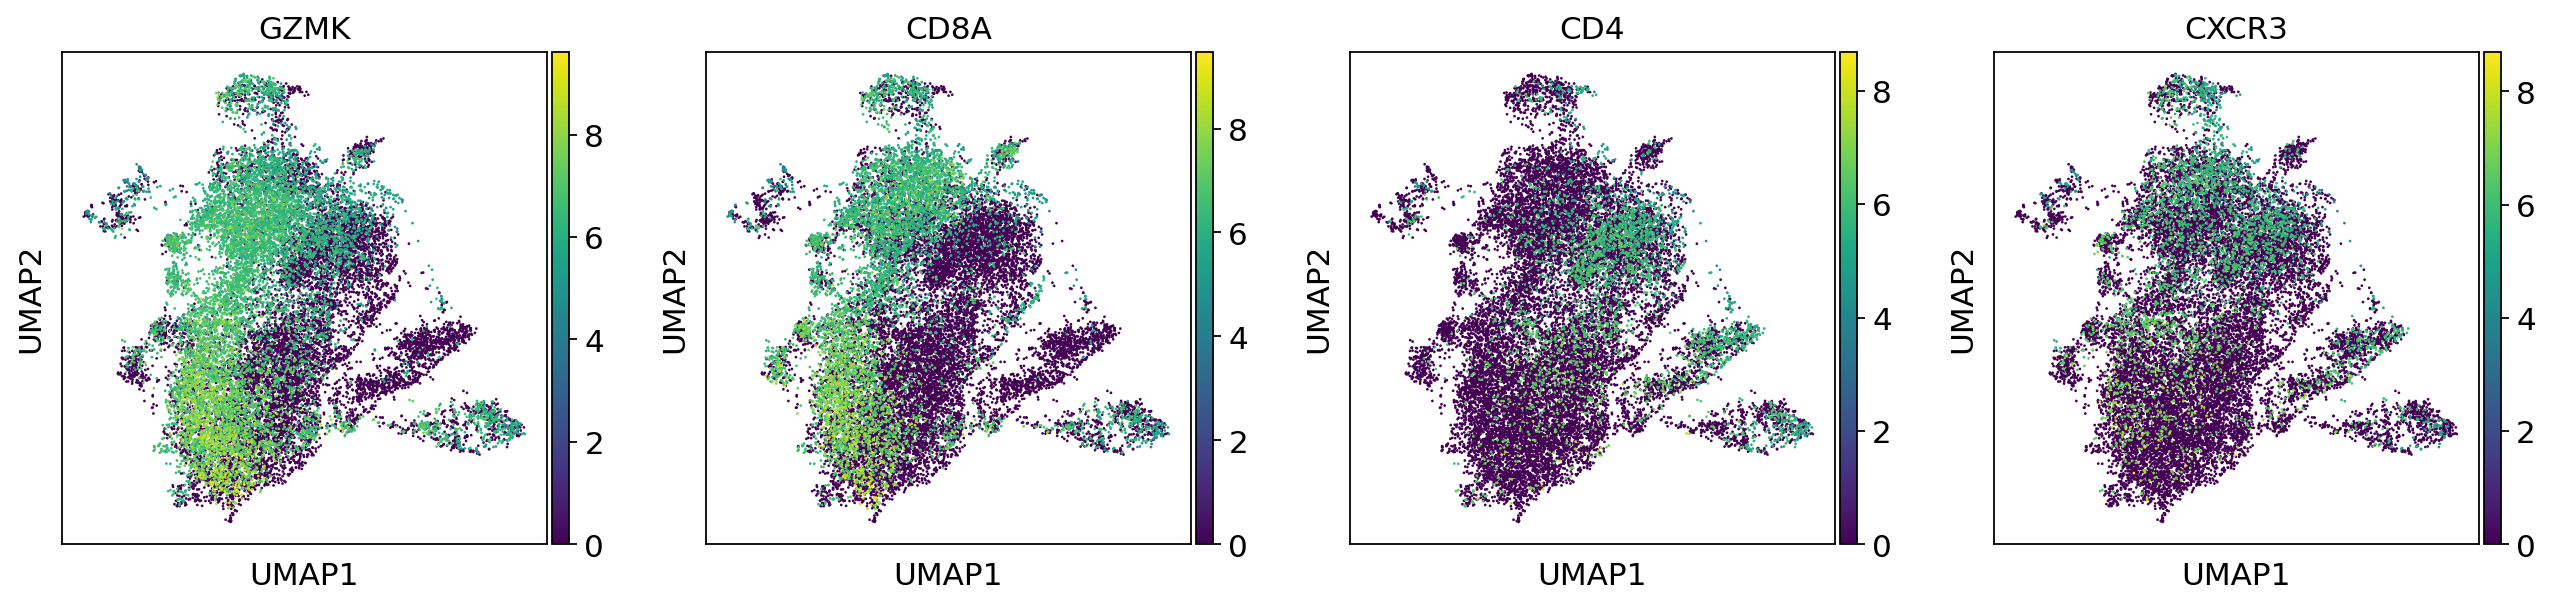

In [57]:
sc.pl.umap(adata,color=["GZMK","CD8A","CD4","CXCR3"])

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


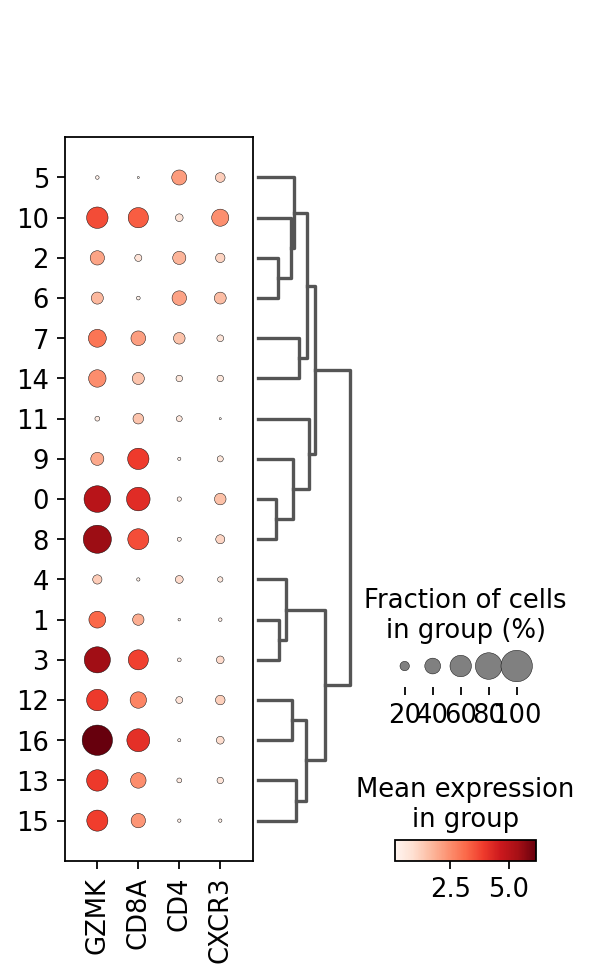

In [58]:
sc.pl.dotplot(adata,groupby="leiden",var_names=["GZMK","CD8A","CD4","CXCR3"],dendrogram=True)

In [59]:
CD8= adata[adata.obs['leiden'].isin(['10','7','14','9','0','8','3','12','16','13','15','1']),]

In [60]:
CD8.write("/home/lugli/spuccio/Projects/SP039/GBmap/TcellCD8_Data.h5ad")